In [301]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import zscore
import warnings
warnings.filterwarnings('ignore')

In [302]:
file_path = r'C:\Users\User\OneDrive\Desktop\task\space_titanic\train.csv'

df = pd.read_csv(file_path)
df

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,False
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,False
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,False


In [303]:
df.isna().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [304]:
df['Side'] = df['Cabin'].str.split('/', expand=True)[2]
df.drop(['Name', 'Cabin','PassengerId'], inplace=True, axis=1)

In [305]:
for col in df.select_dtypes(include=['float64']).columns:
    if col != 'Age':
        df.loc[df['CryoSleep'] == True, col] = df.loc[df['CryoSleep'] == True, col].fillna(0)

df.loc[df[['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']].gt(0).any(axis=1), 'CryoSleep'] = False
df.loc[df[['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']].eq(0).any(axis=1), 'CryoSleep'] = True

destination_to_homeplanet_mode = df.groupby('Destination')['HomePlanet'].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
homeplanet_to_destination_mode = df.groupby('HomePlanet')['Destination'].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
df['HomePlanet'] = df['HomePlanet'].fillna(df['Destination'].map(destination_to_homeplanet_mode))
df['Destination'] = df['Destination'].fillna(df['HomePlanet'].map(homeplanet_to_destination_mode))

df['Age'] = df['Age'].fillna(df['Age'].median())
df['VIP'] = df['VIP'].fillna(df['VIP'].mode()[0])
df['Side'] = df['Side'].fillna(df['Side'].mode()[0])

In [306]:
spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

for col in spending_cols:
    df[col] = df[col].fillna(df[col].mean())

In [307]:
df[df.isnull().any(axis=1)]

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Side
347,NaN,True,NaN,23.0,False,348.0,0.0,0.0,4.0,368.0,False,P
5208,NaN,True,NaN,43.0,False,1.0,0.0,213.0,7.0,701.0,True,S
5687,NaN,True,NaN,52.0,False,0.0,645.0,0.0,0.0,395.0,True,S
6629,NaN,True,NaN,12.0,False,0.0,0.0,0.0,0.0,0.0,False,P


In [308]:
df = df.dropna(subset=['HomePlanet', 'Destination'])

In [309]:
df.isna().sum()

HomePlanet      0
CryoSleep       0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Transported     0
Side            0
dtype: int64

In [310]:
df['Transported'] = df['Transported'].map({True: 1, False: 0})

In [311]:
X,y = df.drop(['Transported'], axis=1), df['Transported'].copy()

In [312]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_cols = X.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'bool', 'category']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

df_processed = pipeline.fit_transform(X)

In [313]:
ohe = pipeline.named_steps['preprocessor'].named_transformers_['cat']
encoded_cols = ohe.get_feature_names_out(categorical_cols)

all_columns = list(numeric_cols) + list(encoded_cols)

X_train = pd.DataFrame(df_processed, columns=all_columns)
X_train.reset_index(drop=True, inplace=True)

In [314]:
y.reset_index(drop=True, inplace=True)

In [315]:
X_train.shape, y.shape

((8689, 18), (8689,))

##### Detecting outliers

In [316]:
z_scores = X_train.select_dtypes(include='number').apply(zscore)
outliers = (z_scores.abs() > 3)
train_outliers = X_train[outliers.any(axis=1)]
train_outliers

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,CryoSleep_False,CryoSleep_True,Destination_55 Cancri e,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,VIP_False,VIP_True,Side_P,Side_S
1,-0.333940,-0.172645,-0.279257,-0.245639,0.213371,-0.228113,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
2,2.037109,-0.272625,1.956809,-0.287460,5.693431,-0.223703,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
4,-0.891834,0.121234,-0.241018,-0.034862,0.227591,-0.265159,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
5,1.060795,-0.337763,0.017882,-0.287460,-0.015928,-0.266923,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
11,1.130531,-0.278684,4.288160,0.697839,-0.176792,-0.157550,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8668,2.246319,-0.337763,-0.284899,-0.287460,-0.274555,-0.266923,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
8672,-0.473414,-0.337763,-0.284899,-0.287460,-0.274555,-0.266923,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
8679,-0.543150,-0.207487,-0.283019,-0.038208,-0.089694,0.023269,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
8684,0.851584,-0.337763,3.989767,-0.287460,1.185668,-0.201652,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0


In [317]:
# to have 2 datasets with and without outliers
outliers_indexes = X_train[outliers.any(axis=1)].index
X_train_normal = X_train.drop(index = outliers_indexes)
y_normal = y.drop(index = outliers_indexes)

In [318]:
from sklearn.model_selection import train_test_split

X_train,X_test, y_train,y_test = train_test_split(X_train_normal,y_normal,test_size=0.2, random_state=42)

In [319]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(random_state=42),
    "SGD Classifier": SGDClassifier(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_train)

    acc = accuracy_score(y_train, y_pred)
    prec = precision_score(y_train, y_pred)
    rec = recall_score(y_train, y_pred)
    f1 = f1_score(y_train, y_pred)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1
    })
    
metrics_df_train = pd.DataFrame(results)
metrics_df_train

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.785059,0.768874,0.854245,0.809314
1,Random Forest,0.927496,0.905746,0.964593,0.934243
2,SVM,0.796072,0.775598,0.869715,0.819964
3,SGD Classifier,0.776065,0.735302,0.907185,0.812250


##### evaluation on test

In [329]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(random_state=42),
    "SGD Classifier": SGDClassifier(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1
    })
    
metrics_df_train = pd.DataFrame(results)
metrics_df_train

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.793837,0.785436,0.838889,0.811283
1,Random Forest,0.775495,0.800872,0.765278,0.782670
2,SVM,0.796772,0.779319,0.858333,0.816920
3,SGD Classifier,0.779164,0.741082,0.894444,0.810573


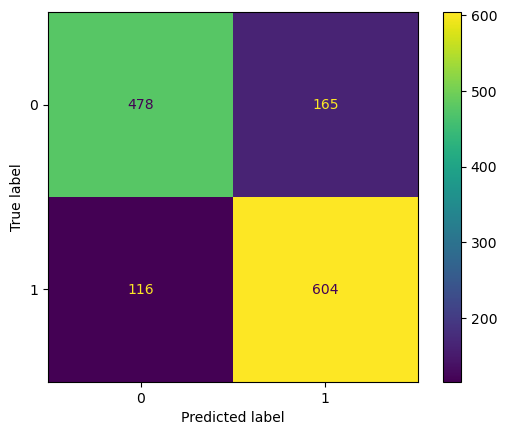

In [340]:
from sklearn.metrics import ConfusionMatrixDisplay,confusion_matrix

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train,y_train)

cm = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test,log_reg.predict(X_test)), display_labels=[0,1]).plot()

In [338]:
pd.Series(log_reg.predict(X_test)).value_counts()

1    769
0    594
Name: count, dtype: int64